# Plotting HERCULES structures

In [2]:
#SJL 11/15
#Script to plot a given structure and print out its essential features

#import required modules
import numpy as np
import scipy as sp
from scipy import constants as const
import sys
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import pylab
import matplotlib.gridspec as gridspec

#Here you will need to point to HERCULES structures on your machine
from HERCULES_structures import *


In [30]:
###############################################################
###############################################################
###############################################################
#PARAMS

#the path to the structure file you want to plot
fname='./output/M1.9PyroSCmeltSMwarm_L8.18327_N200_Nm400_k6_f021_p10_l1_0_1.5_final'
#fname='./output/M.0017PyroSCmantleSMwarm_L0.000102862_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final'

###############################################################
#define blank planet and parameter classes
params=HERCULES_parameters()
params.flag_output_format=1
params.thermo_var_output=['T','S','E']
p=HERCULES_planet()

#read in HERCULES output
file = open(fname, "rb")
params.read_binary(file)
p.read_binary(file,1,['T','S','E'])
file.close()


PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1


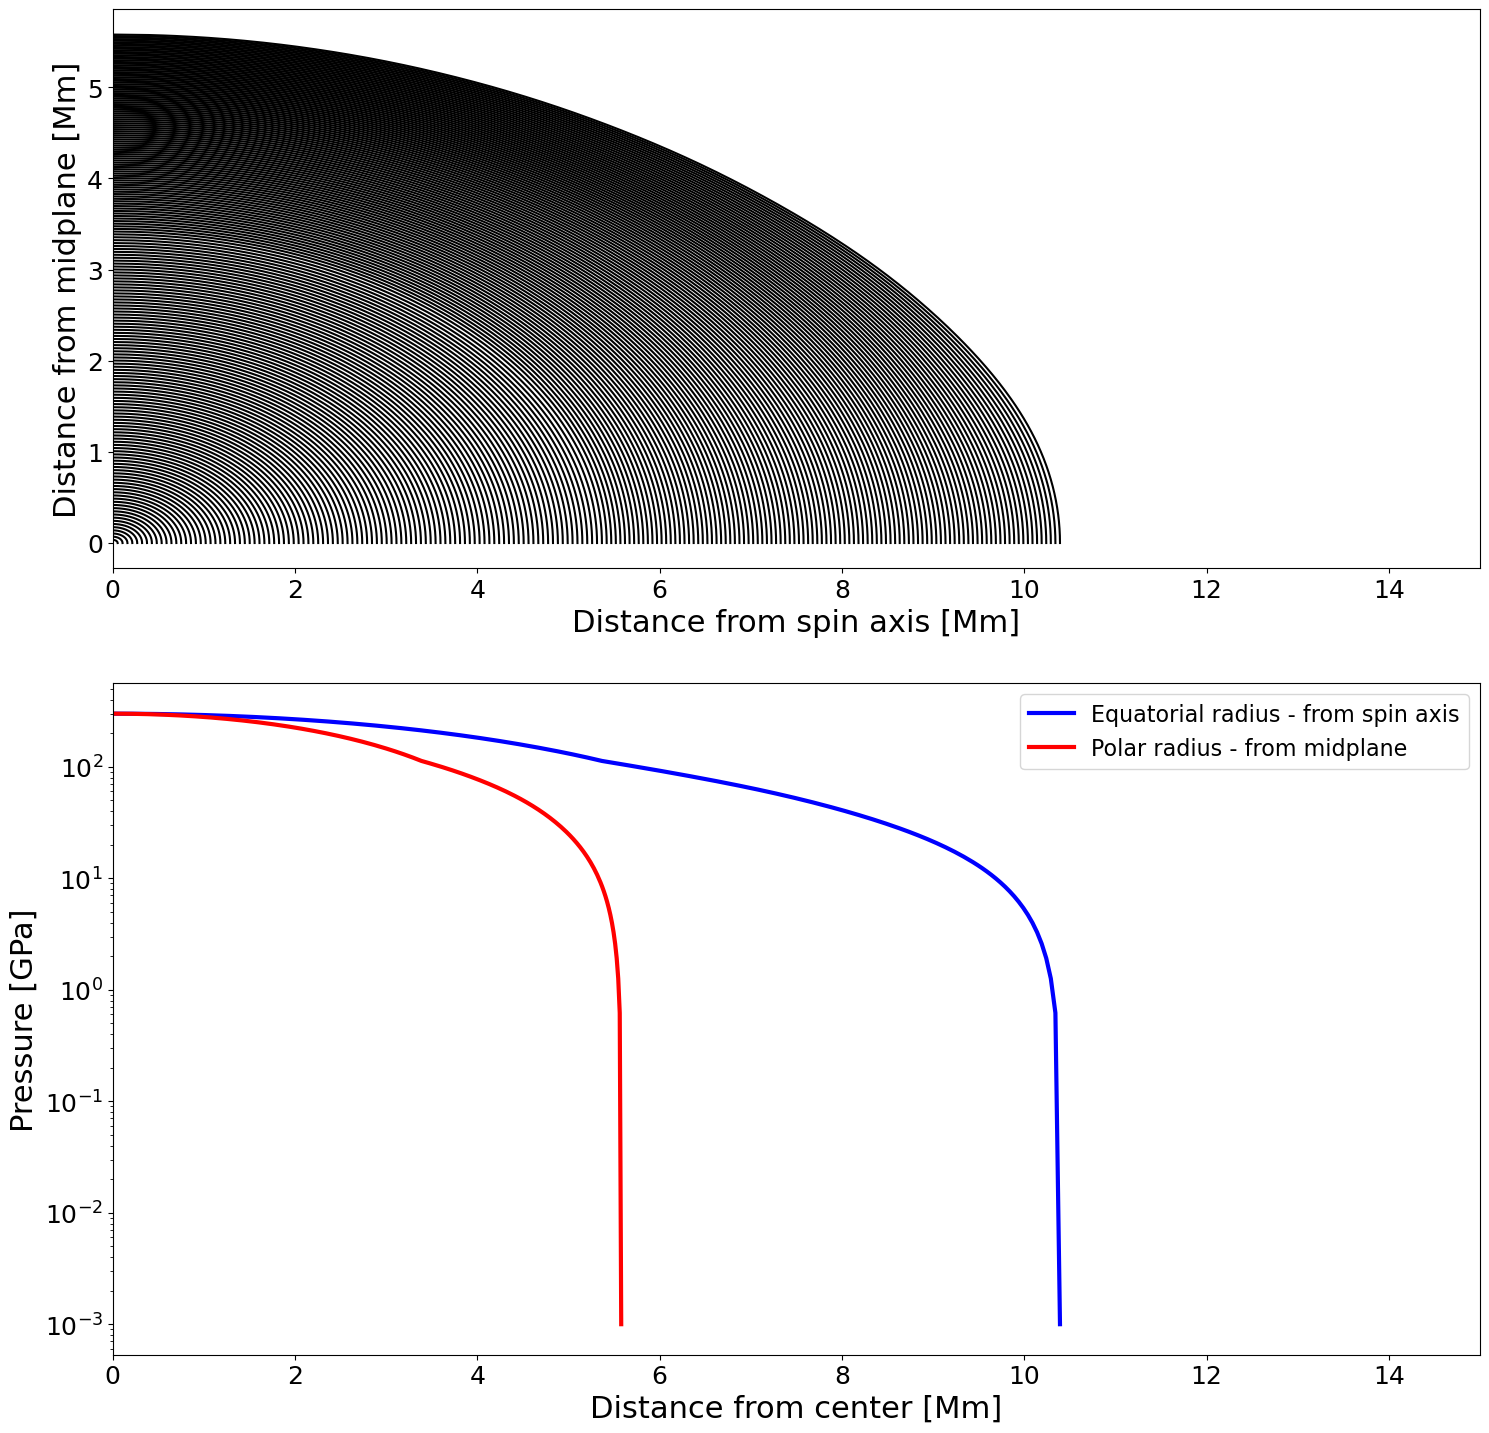

In [31]:
fig,ax=plt.subplots(2,1,figsize=[15,15])

mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)


for i in np.arange(0, p.Nlayer):
    ax[0].plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/1E6, '-', color='k', linewidth=1.5)
ax[0].set_xlim([0,15])
ax[0].set_aspect('equal')
#plt.setp(ax[0].get_xticklabels(), visible=True)
ax[0].set_ylabel('Distance from midplane [Mm]',size=22)
ax[0].set_xlabel('Distance from spin axis [Mm]',size=22)
#ax1.hold(False)    
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].tick_params(axis='both', which='minor', labelsize=18)

#plot the pressure profile
radius=np.asarray([])
radius2=np.asarray([])
press=np.asarray([])
for i in np.arange(p.Nlayer):
    radius=np.append(radius, np.asarray(p.layers[i].a/1.0E6))
    radius2=np.append(radius2,np.asarray(p.layers[i].b/1.0E6))
    press=np.append(press, np.asarray(p.press[i]/1.0E9))
radius=np.append(radius, np.asarray(0.0))
radius2=np.append(radius2, np.asarray(0.0))
press=np.append(press, np.asarray(p.pcore/1.0E9))

#ax2.hold(True)
ax[1].plot(radius, press, '-', color='blue', linewidth=3,label='Equatorial radius - from spin axis')
ax[1].plot(radius2, press, '-', color='red', linewidth=3,label='Polar radius - from midplane')

ax[1].set_xlim([0,15])
#ax[1].set_ylim(1.e-5,None)
ax[1].set_yscale('log')
ax[1].set_xlabel('Distance from center [Mm]',size=22)
ax[1].set_ylabel('Pressure [GPa]',size=22)
#ax2.hold(False)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].tick_params(axis='both', which='minor', labelsize=18)
ax[1].legend(fontsize=16)

#ax2.hold(True)
#ax[2].plot(radius2, press, '-', color='k', linewidth=1.5)

#ax[2].set_xlim([0,5])
##ax[1].set_ylim(1.e-5,None)
#ax[2].set_yscale('log')
#ax[2].set_xlabel('Distance from midplane (Polar) [Mm]',size=22)
#ax[2].set_ylabel('Pressure [GPa]',size=22)
#ax2.hold(False)
#ax[2].tick_params(axis='both', which='major', labelsize=18)
#ax[2].tick_params(axis='both', which='minor', labelsize=18)


plt.tight_layout()
imname='corol_P_profile_both'+'.pdf'
plt.savefig(imname)
plt.show()

In [9]:
ind=np.where(p.flag_material>0)[0][0]
a=p.layers[ind].a
b=p.layers[ind].b
b_alt=p.layers[ind].xi[-1]*p.layers[ind].a
print(a,b,b_alt)
print(p.aspect)

556337.5268363586 549392.4317361478 549392.4317361478
0.9864444829424538


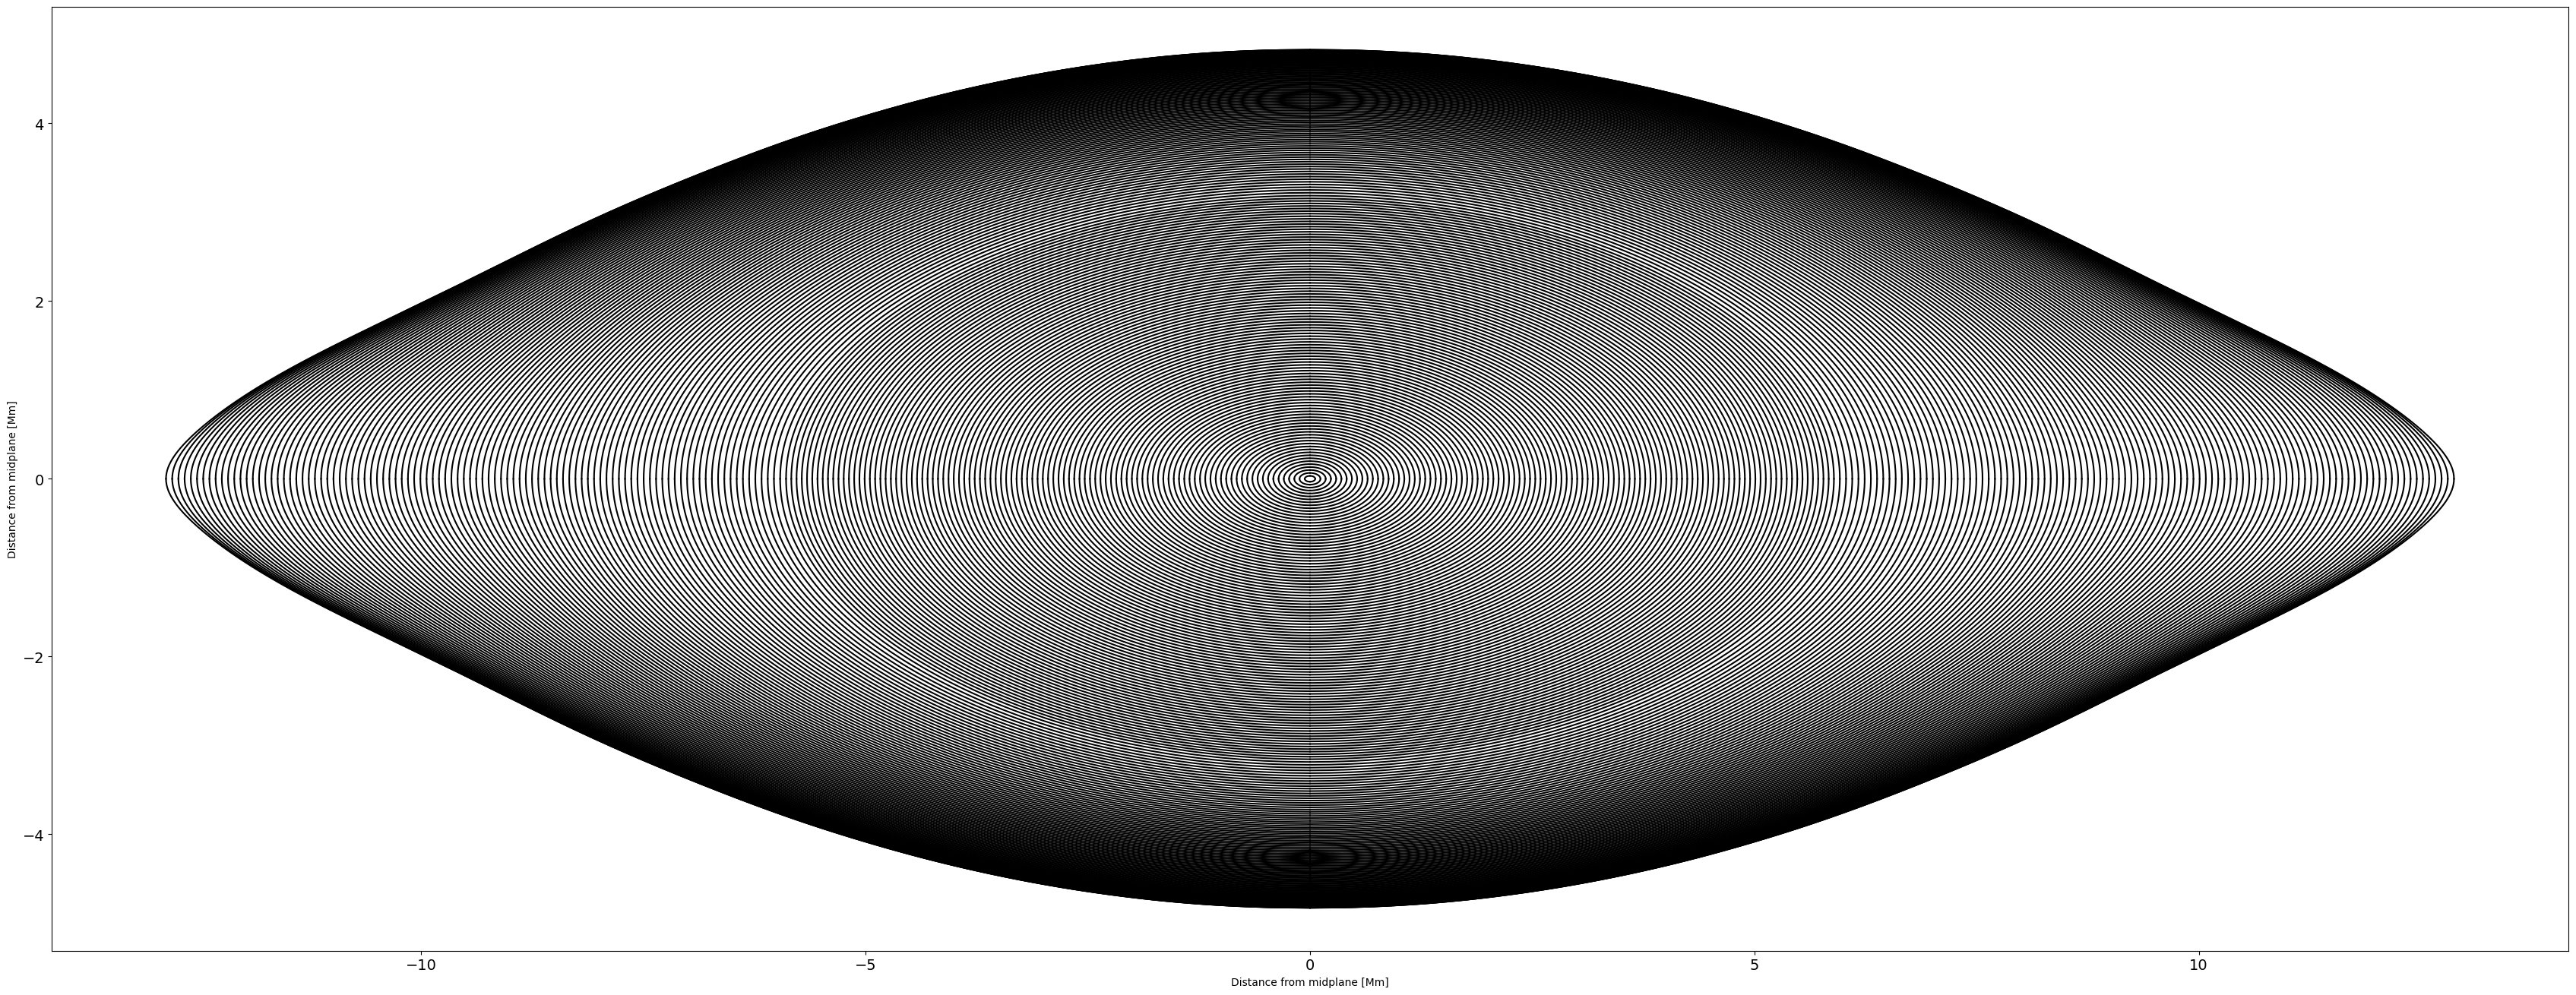

In [6]:
fig,ax=plt.subplots(1,1,figsize=[34,17])
for i in np.arange(0, p.Nlayer):
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/1E6, '-', color='k', linewidth=1.5)
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/-1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/1E6, '-', color='k', linewidth=1.5)
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/-1E6, '-', color='k', linewidth=1.5)
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/-1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/-1E6, '-', color='k', linewidth=1.5)
#ax.set_xlim([0,1.5])
ax.set_aspect('equal')
#plt.setp(ax[0].get_xticklabels(), visible=True)
ax.set_ylabel('Distance from midplane [Mm]')
ax.set_xlabel('Distance from midplane [Mm]')
#ax1.hold(False)    

plt.tight_layout()
plt.show()

In [7]:
np.sqrt(1-0.81267**2)

0.5827241809810195

In [23]:
## writing code for volume scaling
volume=0
j=0
for i in range(1,np.size(p.layers[j].xi)):
    dy=p.layers[j].xi[i]*p.layers[j].a*p.layers[j].mu[i]/1E6-p.layers[j].xi[i-1]*p.layers[j].a*p.layers[j].mu[i-1]/1E6
    x=p.layers[j].xi[i-1]*p.layers[j].a*np.sqrt(np.absolute(1-p.layers[j].mu[i-1]**2))/1E6
    v=np.pi*x**2*dy
    volume+=v
print(volume)

v1=1.5114077606842744

1302.3504798313393


In [24]:
#PARAMS

#the path to the structure file you want to plot
fname2='./output/M0.5PyroSCwarmSMwarm_L1.37378_N150_Nm400_k6_f121_p10_l1_0_1.5_final'

###############################################################
#define blank planet and parameter classes
params2=HERCULES_parameters()
params2.flag_output_format=0
params2.thermo_var_output=['T','S','E']
p2=HERCULES_planet()

#read in HERCULES output
file2 = open(fname2, "rb")
params2.read_binary(file2)
p2.read_binary(file2,0,['T','S','E'])
file2.close()


PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 0
OUTPUT FORMAT 0
OUTPUT READ SUCCESSFUL WITH FORMAT 0


In [25]:
## writing code for volume scaling
volume1=0
for i in range(1,np.size(p.layers[j].xi)):
    dy=p2.layers[j].xi[i]*p2.layers[j].a*p2.layers[j].mu[i]/1E6-p2.layers[j].xi[i-1]*p2.layers[j].a*p2.layers[j].mu[i-1]/1E6
    #dy/=vfrac
    x=p2.layers[j].xi[i-1]*p2.layers[j].a*np.sqrt(np.absolute(1-p2.layers[j].mu[i-1]**2))/1E6
    #x/=vfrac
    v=np.pi*x**2*dy
    volume1+=v
print(volume1)
vfrac=(volume1/v1)**(1/3)
volume2=0
j=0
for i in range(1,np.size(p.layers[j].xi)):
    dy=p2.layers[j].xi[i]*p2.layers[j].a*p2.layers[j].mu[i]/1E6-p2.layers[j].xi[i-1]*p2.layers[j].a*p2.layers[j].mu[i-1]/1E6
    dy/=vfrac
    x=p2.layers[j].xi[i-1]*p2.layers[j].a*np.sqrt(np.absolute(1-p2.layers[j].mu[i-1]**2))/1E6
    x/=vfrac
    v=np.pi*x**2*dy
    volume2+=v
print(volume2)

400.4783027099091
1.5114077606842733


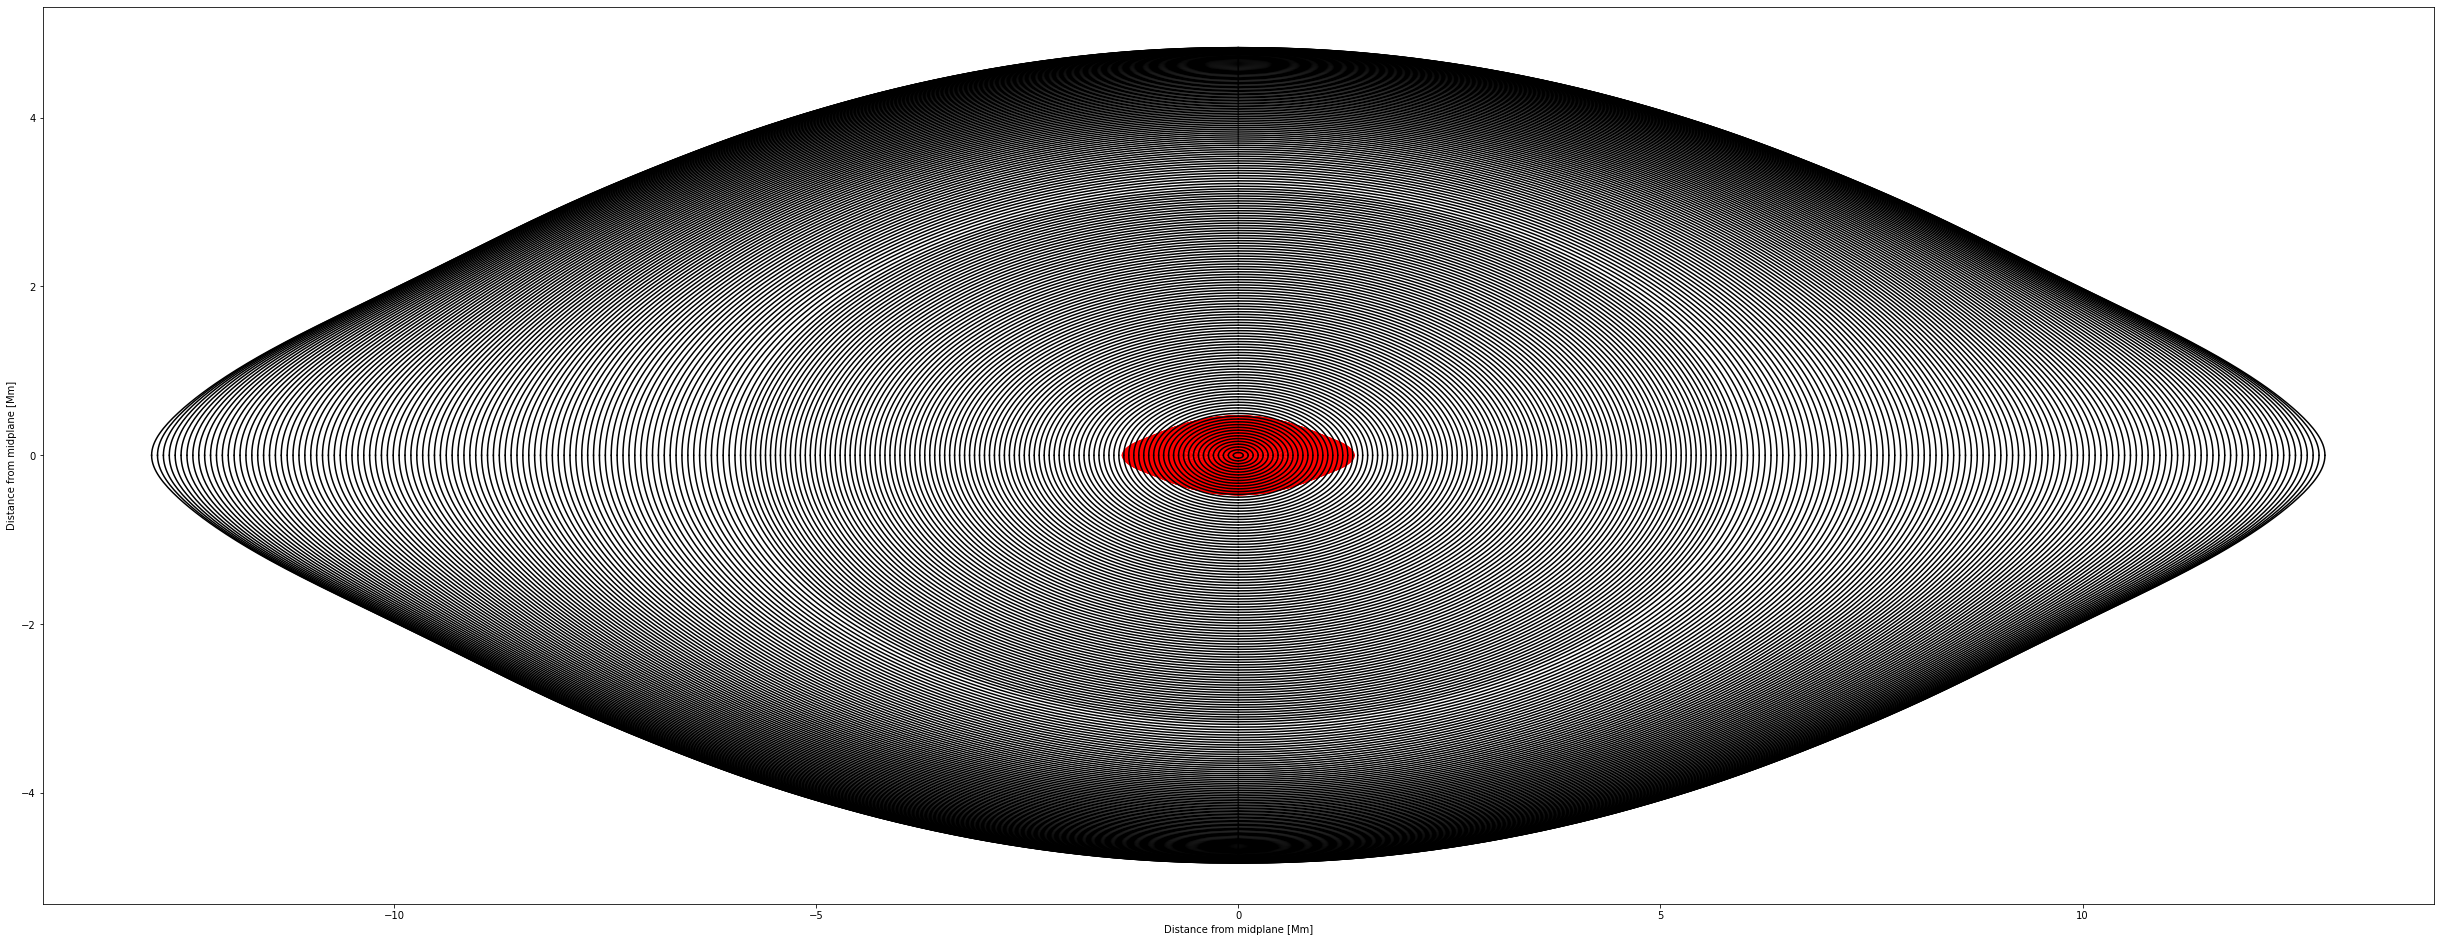

In [26]:
fig,ax=plt.subplots(1,1,figsize=[34,17])

core_layer=p2.Nmaterial-1
temp=np.where(p2.flag_material==core_layer)[0]
ind=temp[0]
ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/1E6/vfrac, '-', color='blue', linewidth=5)
ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/-1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/1E6/vfrac, '-', color='blue', linewidth=5)
ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/-1E6/vfrac, '-', color='blue', linewidth=5)
ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/-1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/-1E6/vfrac, '-', color='blue', linewidth=5)

for i in np.arange(0, p2.Nlayer):
    ax.plot(p2.layers[i].xi*p2.layers[i].a*np.sqrt(np.absolute(1-p2.layers[i].mu**2))/1E6/vfrac, p2.layers[i].xi*p2.layers[i].a*p2.layers[i].mu/1E6/vfrac, '-', color='red', linewidth=1.5)
    ax.plot(p2.layers[i].xi*p2.layers[i].a*np.sqrt(np.absolute(1-p2.layers[i].mu**2))/-1E6/vfrac, p2.layers[i].xi*p2.layers[i].a*p2.layers[i].mu/1E6/vfrac, '-', color='red', linewidth=1.5)
    ax.plot(p2.layers[i].xi*p2.layers[i].a*np.sqrt(np.absolute(1-p2.layers[i].mu**2))/1E6/vfrac, p2.layers[i].xi*p2.layers[i].a*p2.layers[i].mu/-1E6/vfrac, '-', color='red', linewidth=1.5)
    ax.plot(p2.layers[i].xi*p2.layers[i].a*np.sqrt(np.absolute(1-p2.layers[i].mu**2))/-1E6/vfrac, p2.layers[i].xi*p2.layers[i].a*p2.layers[i].mu/-1E6/vfrac, '-', color='red', linewidth=1.5)

for i in np.arange(0, p.Nlayer):
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/1E6, '-', color='k', linewidth=1.5)
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/-1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/1E6, '-', color='k', linewidth=1.5)
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/-1E6, '-', color='k', linewidth=1.5)
    ax.plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/-1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/-1E6, '-', color='k', linewidth=1.5)
    
#ax.set_xlim([0,1.5])
ax.set_aspect('equal')
#plt.setp(ax[0].get_xticklabels(), visible=True)
ax.set_ylabel('Distance from midplane [Mm]')
ax.set_xlabel('Distance from midplane [Mm]')
#ax1.hold(False)    

plt.tight_layout()


In [27]:
fnames=['./output/M.0017PyroSCmantleSMwarm_L0.00012447_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final',
    './output/M.005PyroSCmantleSMwarm_L0.000746107_N150_Nm400_k6_f121_p1_l1_0_1.5_final',
    './output/M.017PyroSCmantleSMwarm_L0.00556398_N200_Nm400_k6_f021_p1_l1_0_1.5_final',
    './output/M.05PyroSCmantleSMwarm_L0.0338559_N200_Nm400_k6_f021_p10_l1_0_1.5_final',
    './output/M0.17PyroSCmantleSMwarm_L0.239186_N150_Nm400_k6_f021_p10_l1_0_1.5_final',
    './output/M0.55PyroSCwarmSMwarm_L1.61451_N150_Nm400_k6_f121_p10_l1_0_1.5_final',
    './output/M0.91PyroSCwarmSMwarm_L3.56832_N150_Nm400_k6_f121_p10_l1_0_1.5_final',
    './output/M1.9PyroSCmeltSMwarm_L11.2282_N200_Nm400_k6_f021_p10_l1_0_1.5_final'
    ]

filelist = np.array([])
masslist = np.array([])
planetdict = {}
hercdict = {}
for filename in fnames:
    tparams = HERCULES_parameters()
    tparams.flag_output_format=1
    tparams.thermo_var_output=['T','S','E']
    tplanet = HERCULES_planet()
    tplanet.flag_output_format=1
    tplanet.thermo_var_output=['T','S','E']
    try:   
        try:
            with open(filename, "rb") as file:
                tparams.read_binary(file)
                tplanet.read_binary(file,1,['T','S','E'])
        except:
            print('ERROR: READ WITH FORMAT 1 UNSUCCESSFUL')
            tparams.flag_output_format=0
            tplanet.flag_output_format=0
            with open(filename, "rb") as file:
                tparams.read_binary(file)
                tplanet.read_binary(file,0,['T','S','E'])

        tplanet.calc_pCMB()
        print('Loaded HERCULES output ',filename)
        #self.keys=np.append(self.keys,keyparams)
        #self.paramsdict[keyparams]=tparams
        #self.planetdict[keyparams]=tplanet
        #self.Ltot=np.append(self.Ltot,tplanet.Ltot)
        #self.PCMB=np.append(self.PCMB,tplanet.pCMB)
        #self.Pcore=np.append(self.Pcore,tplanet.pcore)
        #self.r1=np.append(self.r1,tplanet.amax)
        #self.w=np.append(self.w,tplanet.omega_rot)
        #core_layer=tplanet.Nmaterial-1
        #ind=np.where(tplanet.flag_material==core_layer)[0]
        #self.rCMB=np.append(self.rCMB,tplanet.layers[ind[0]].a)
        hercdict[filename]=tplanet
    except:
        print('ERROR: READ UNSUCCESSFUL. SKIPPING FILE')
        

PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  ./output/M.0017PyroSCmantleSMwarm_L0.00012447_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 0
OUTPUT FORMAT 0
OUTPUT READ SUCCESSFUL WITH FORMAT 0
Loaded HERCULES output  ./output/M.005PyroSCmantleSMwarm_L0.000746107_N150_Nm400_k6_f121_p1_l1_0_1.5_final
PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  ./output/M.017PyroSCmantleSMwarm_L0.00556398_N200_Nm400_k6_f021_p1_l1_0_1.5_final
PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  ./output/M.05PyroSCmantleSMwarm_L0.0338559_N200_Nm400_k6_f021_p10_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 

In [28]:
## writing code for volume scaling
volume=0
j=0
p=hercdict[fnames[0]]
for i in range(1,np.size(p.layers[j].xi)):
    dy=p.layers[j].xi[i]*p.layers[j].a*p.layers[j].mu[i]/1E6-p.layers[j].xi[i-1]*p.layers[j].a*p.layers[j].mu[i-1]/1E6
    x=p.layers[j].xi[i-1]*p.layers[j].a*np.sqrt(np.absolute(1-p.layers[j].mu[i-1]**2))/1E6
    v=np.pi*x**2*dy
    volume+=v
print(volume)
v1=volume

1.5114077606842744


In [29]:
vfracdict={}
for filename in fnames:
    ## writing code for volume scaling
    volume1=0
    p2=hercdict[filename]
    for i in range(1,np.size(p.layers[j].xi)):
        dy=p2.layers[j].xi[i]*p2.layers[j].a*p2.layers[j].mu[i]/1E6-p2.layers[j].xi[i-1]*p2.layers[j].a*p2.layers[j].mu[i-1]/1E6
        #dy/=vfrac
        x=p2.layers[j].xi[i-1]*p2.layers[j].a*np.sqrt(np.absolute(1-p2.layers[j].mu[i-1]**2))/1E6
        #x/=vfrac
        v=np.pi*x**2*dy
        volume1+=v
    print(volume1)
    vfrac=(volume1/v1)**(1/3)
    vfracdict[filename]=vfrac
    volume2=0
    j=0
    for i in range(1,np.size(p.layers[j].xi)):
        dy=p2.layers[j].xi[i]*p2.layers[j].a*p2.layers[j].mu[i]/1E6-p2.layers[j].xi[i-1]*p2.layers[j].a*p2.layers[j].mu[i-1]/1E6
        dy/=vfrac
        x=p2.layers[j].xi[i-1]*p2.layers[j].a*np.sqrt(np.absolute(1-p2.layers[j].mu[i-1]**2))/1E6
        x/=vfrac
        v=np.pi*x**2*dy
        volume2+=v
    print(volume2)

1.5114077606842744
1.5114077606842744
4.513170897905668
1.511407760684274
14.95096179767695
1.5114077606842773
44.177527765679756
1.5114077606842717
142.3278639146324
1.5114077606842724
438.3488445928325
1.511407760684275
693.1634870018162
1.5114077606842737
1318.9876843427078
1.5114077606842715


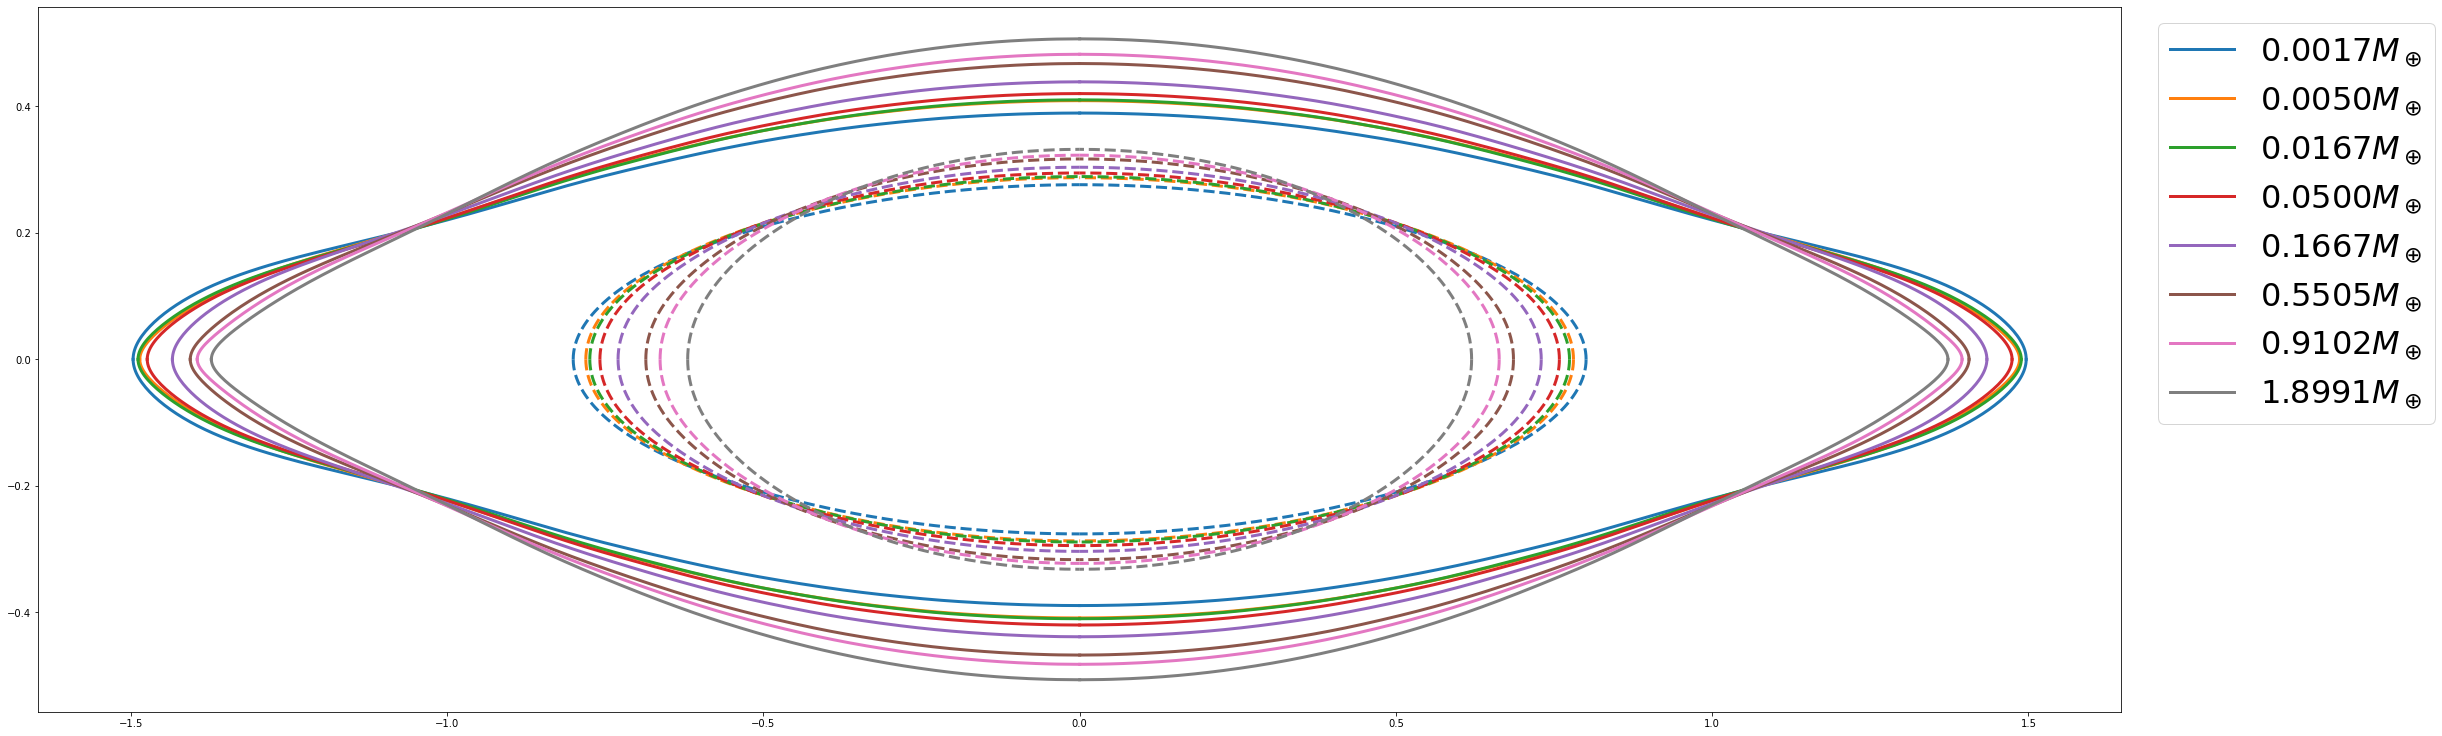

In [31]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
M_earth = 5.972E24 # Earth's mass kg


fig,ax=plt.subplots(1,1,figsize=[34,17])
i=0
for filename in fnames:
    p2=hercdict[filename]
    vfrac=vfracdict[filename]
    core_layer=p2.Nmaterial-1
    temp=np.where(p2.flag_material==core_layer)[0]
    ind=temp[0]
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/1E6/vfrac, '--', c=colors[i], linewidth=3)
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/-1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/1E6/vfrac, '--', c=colors[i], linewidth=3)
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/-1E6/vfrac, '--', c=colors[i], linewidth=3)
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/-1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/-1E6/vfrac, '--', c=colors[i], linewidth=3)
    
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/1E6/vfrac, '-', c=colors[i], linewidth=3,label=r'%.4f$M_\oplus$'%(p2.Mtot/M_earth))
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/-1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/1E6/vfrac, '-', c=colors[i], linewidth=3)
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/-1E6/vfrac, '-', c=colors[i], linewidth=3)
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/-1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/-1E6/vfrac, '-', c=colors[i], linewidth=3)
    
    i+=1
ax.legend(fontsize=32,bbox_to_anchor=(1.01, 1.0),)
ax.set_aspect('equal')
plt.tight_layout()
imname='corol_shape2'+'.pdf'
plt.savefig(imname)
plt.show()

In [21]:
0.05**2+0.08**2+0.07**2

0.013800000000000003

In [23]:
print(np.sqrt(0.013800000000000003))

0.11747340124470732


In [24]:
1.32**2+1.26**+1.49**2

3.412846793578349

In [25]:
print(np.sqrt(3.412846793578349))

1.8473891830305678
